# S2 Inter-Participant Agreement

Measures how similarly participants answer each VQA question, independent of correctness.

Three metrics per question:
- **Exact match** — fraction of pairs with identical normalized text
- **Jaccard** — mean token overlap over all pairs
- **SBERT** — mean cosine similarity of sentence embeddings (semantic)

Then correlates agreement with: human accuracy, model accuracy, question difficulty h(q).

In [1]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr 

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))

VARIANT_ORDER = ['C', 'B', 'A']
VARIANT_LABELS = {'C': 'C (original)', 'B': 'B (weaker)', 'A': 'A (pronominalized)'}

In [2]:
# ── Load human data ───────────────────────────────────────────────────────────
from utils.load_session import load_human_data, check_translation_coverage

participants, common_qids, df, mapper = load_human_data(BASE, min_answers=348)
check_translation_coverage(df, BASE / 'analysis/utils/kr_answer_map.json')

Qualifying participants (>= 348 answers): 23
  8HLCRUY1  answers=348  qids=116
  BEK0Y4W3  answers=402  qids=134
  BTTWUQG4  answers=402  qids=134
  DPCN9S37  answers=348  qids=116
  DYAN3RF8  answers=402  qids=134
  FLWP3ZF7  answers=348  qids=116
  FXDCPFHM  answers=402  qids=134
  HB857QDA  answers=348  qids=116
  HGIX7HE0  answers=402  qids=134
  IV0PL083  answers=402  qids=134
  J09HHJXK  answers=348  qids=116
  J0OU3FTE  answers=372  qids=124
  JOJCF28V  answers=372  qids=124
  K8VD3TYB  answers=348  qids=116
  MPOMQQNU  answers=348  qids=116
  NVF556XP  answers=348  qids=116
  O23790AV  answers=348  qids=116
  OBRNN1JM  answers=402  qids=134
  ON7P7X1E  answers=372  qids=124
  Q4PLE2BH  answers=348  qids=116
  TRFMV4H2  answers=372  qids=124
  Y2IBXIJX  answers=372  qids=124
  ZEF2XJBX  answers=348  qids=116


/home/david/miniconda3/envs/aide/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw Korean strings      : 2042
Already translated      : 2042
Unique canonicals to translate: 0

✓ All Korean answers already mapped.
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations

Common question_ids: 113
Rows: 7797 | questions: 113 | participants: 23
Answers still in Korean (scored 0): 0 / 7797 (0.0%)
Total     : 7797
Translated: 7797  (100.0%)
Untranslated: 0  (0.0%)
✓ All answers translated.


{'total': 7797, 'translated': 7797, 'untranslated': 0, 'added': 0}

In [3]:
# ── Load model results ────────────────────────────────────────────────────────
from utils.load_session import load_model_results

q_ids = set(df['question_id'].tolist())
model_q_acc, MODEL_TYPE, MODELS, ALL_MODELS = load_model_results(BASE, q_ids)

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Loaded vqa_1k_control_inst_blind for: ['Qwen3-VL-8B', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna', 'InternVL-1B', 'InternVL-2B', 'InternVL-8B', 'LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)', 'Qwen3-8B']
  [VLM         ] Qwen3-VL-8B: 112 questions, mean C = 0.473
  [VLM         ] LLaVA-1.5-7B: 113 questions, mean C = 0.472
  [VLM         ] LLaVA-Mistral: 113 questions, mean C = 0.537
  [VLM         ] LLaVA-Vicuna: 113 questions, mean C = 0.516
  [VLM         ] InternVL-1B: 113 questions, mean C = 0.280
  [VLM         ] InternVL-2B: 113 questions, mean C = 0.437
  [VLM         ] InternVL-8B: 113 questions, mean C = 0.366
  [LM-decoder  ] LLaVA-1.5 (LM): 113 questions, mean C = 0.537
  [LM-decoder  ] LLaVA-Mistral (LM): 113 questions, mean C = 0.537
  [LM-decoder  ] LLaVA-Vicuna (LM): 113 questions, mean C = 0.445
  [Backbone LLM] Qwen3-8

In [4]:
# ── Compute inter-participant agreement (all 3 methods) ───────────────────────
from utils.agreement import compute_question_agreement

# Compute per variant — takes ~1-2 min (SBERT encoding)
agree = {}
for var in VARIANT_ORDER:
    print(f'\n── Variant {var} ──')
    agree[var] = compute_question_agreement(
        df, common_qids,
        methods=['exact', 'jaccard', 'sbert'],
        answer_col='answer_en',
        variant=var,
    )

# Combine into one DataFrame with variant suffix
agree_all = pd.concat(
    {var: agree[var] for var in VARIANT_ORDER}, axis=1
)
agree_all.columns = [f'{m}_{v}' for v, m in agree_all.columns]
print('\nAgreement table shape:', agree_all.shape)
agree_all.describe().round(3)


── Variant C ──
Loading SBERT model: all-MiniLM-L6-v2 …
Agreement computed for 113 questions (variant=C)
  exact: mean=0.227  std=0.211
  jaccard: mean=0.239  std=0.207
  sbert: mean=0.596  std=0.217

── Variant B ──
Loading SBERT model: all-MiniLM-L6-v2 …
Agreement computed for 113 questions (variant=B)
  exact: mean=0.229  std=0.238
  jaccard: mean=0.237  std=0.234
  sbert: mean=0.585  std=0.227

── Variant A ──
Loading SBERT model: all-MiniLM-L6-v2 …
Agreement computed for 113 questions (variant=A)
  exact: mean=0.204  std=0.214
  jaccard: mean=0.210  std=0.211
  sbert: mean=0.568  std=0.232

Agreement table shape: (113, 9)


,exact_C,jaccard_C,sbert_C,exact_B,jaccard_B,sbert_B,exact_A,jaccard_A,sbert_A
count,113.000,113.000,113.000,113.000,113.000,113.000,113.000,113.000,113.000
mean,0.227,0.239,0.596,0.229,0.237,0.585,0.204,0.210,0.568
std,0.211,0.207,0.217,0.238,0.234,0.227,0.214,0.211,0.232
min,0.004,0.007,0.195,0.000,0.003,0.174,0.000,0.000,0.196
25%,0.055,0.068,0.400,0.051,0.058,0.386,0.040,0.043,0.352
50%,0.150,0.158,0.599,0.123,0.142,0.575,0.123,0.126,0.582
75%,0.368,0.390,0.802,0.474,0.478,0.809,0.300,0.313,0.784
max,0.834,0.834,0.956,0.834,0.834,0.956,0.913,0.913,0.977


/tmp/ipykernel_3303451/1933420324.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
/tmp/ipykernel_3303451/1933420324.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
/tmp/ipykernel_3303451/1933420324.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],


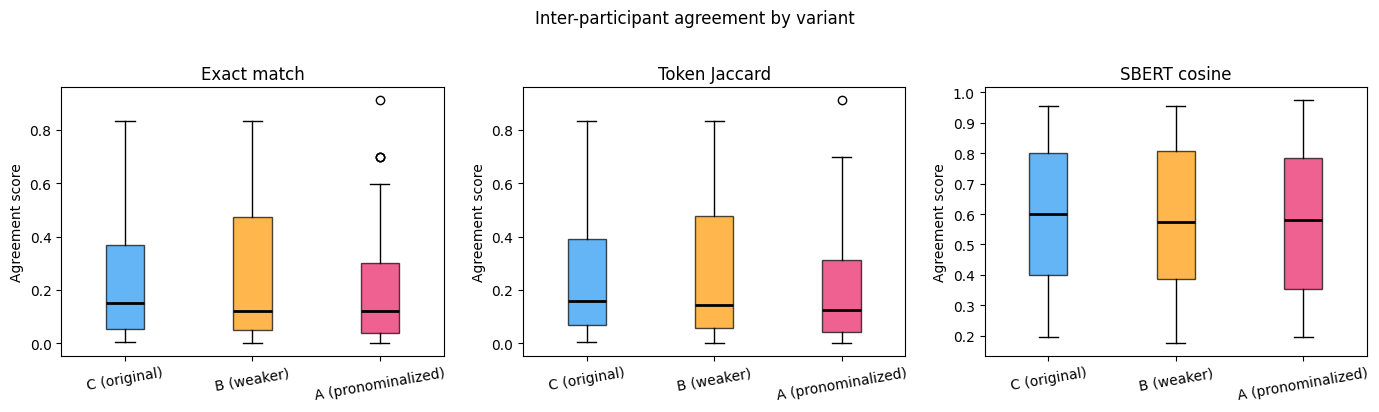

In [5]:
# ── Agreement by variant — box plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
methods = [('exact', 'Exact match'), ('jaccard', 'Token Jaccard'), ('sbert', 'SBERT cosine')]
colors  = {'C': '#2196F3', 'B': '#FF9800', 'A': '#E91E63'}

for ax, (meth, title) in zip(axes, methods):
    data = [agree[var][meth].dropna().values for var in VARIANT_ORDER]
    bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
                    patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, var in zip(bp['boxes'], VARIANT_ORDER):
        patch.set_facecolor(colors[var])
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel('Agreement score')
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Inter-participant agreement by variant', y=1.02)
plt.tight_layout()
plt.show()

Pearson r — SBERT agreement vs human accuracy:
  Variant C: r=0.702  p=0.000  n=113
  Variant B: r=0.678  p=0.000  n=113
  Variant A: r=0.740  p=0.000  n=113


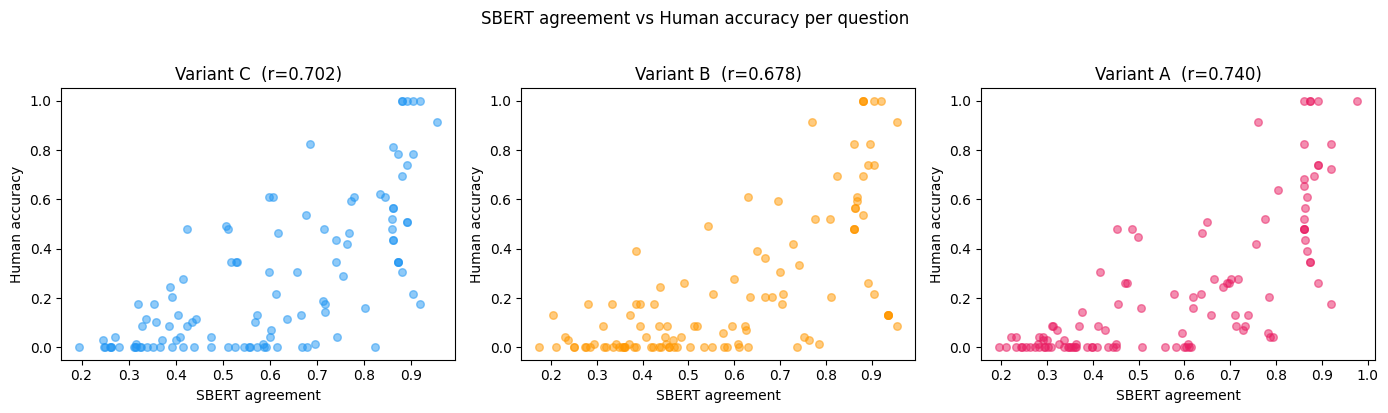

In [6]:
# ── Correlation: agreement vs human accuracy ──────────────────────────────────
# h_acc(q) = mean human accuracy per question per variant
h_acc = df.groupby(['question_id', 'variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]

print('Pearson r — SBERT agreement vs human accuracy:')
for var in VARIANT_ORDER:
    merged = agree[var][['sbert']].join(h_acc[[var]].rename(columns={var: 'acc'})).dropna()
    r, p = pearsonr(merged['sbert'], merged['acc'])
    print(f'  Variant {var}: r={r:.3f}  p={p:.3f}  n={len(merged)}')

# Scatter for variant C
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, VARIANT_ORDER):
    merged = agree[var][['sbert', 'exact', 'jaccard']].join(
        h_acc[[var]].rename(columns={var: 'acc'})).dropna()
    ax.scatter(merged['sbert'], merged['acc'], alpha=0.5, color=colors[var], s=30)
    r, _ = pearsonr(merged['sbert'], merged['acc'])
    ax.set_xlabel('SBERT agreement')
    ax.set_ylabel('Human accuracy')
    ax.set_title(f'Variant {var}  (r={r:.3f})')

plt.suptitle('SBERT agreement vs Human accuracy per question', y=1.02)
plt.tight_layout()
plt.show()

Correlations — variant C agreement vs model avg accuracy:
  exact   : r=0.616  p=0.000
  jaccard : r=0.604  p=0.000
  sbert   : r=0.604  p=0.000


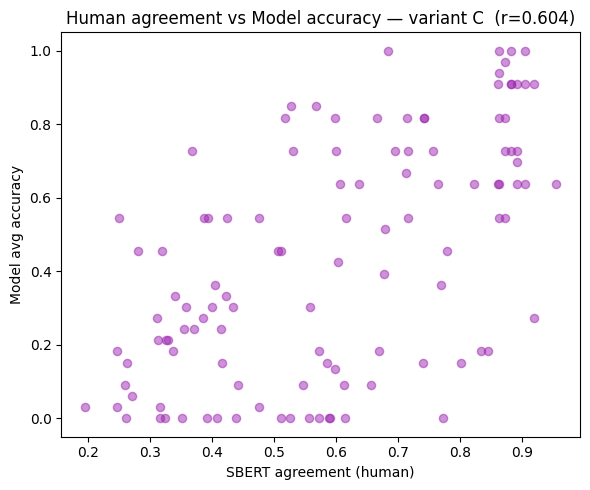

In [7]:
# ── Correlation: agreement vs model accuracy ──────────────────────────────────
# Average model accuracy per question (across all models, variant C)
model_avg_C = pd.concat(
    [mdf[['C']].rename(columns={'C': label}) for label, mdf in model_q_acc.items()],
    axis=1
).mean(axis=1).rename('model_avg_acc')

merged_m = agree['C'][['sbert', 'exact', 'jaccard']].join(model_avg_C).dropna()
print('Correlations — variant C agreement vs model avg accuracy:')
for meth in ['exact', 'jaccard', 'sbert']:
    r, p = pearsonr(merged_m[meth], merged_m['model_avg_acc'])
    print(f'  {meth:8}: r={r:.3f}  p={p:.3f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(merged_m['sbert'], merged_m['model_avg_acc'], alpha=0.5, color='#9C27B0', s=35)
r, _ = pearsonr(merged_m['sbert'], merged_m['model_avg_acc'])
ax.set_xlabel('SBERT agreement (human)')
ax.set_ylabel('Model avg accuracy')
ax.set_title(f'Human agreement vs Model accuracy — variant C  (r={r:.3f})')
plt.tight_layout()
plt.show()

Agreement by entity type (variant C, sorted by SBERT):
         sbert  exact  jaccard   N
ent                               
food     0.648  0.278    0.294  16
animal   0.622  0.252    0.267  17
object   0.615  0.216    0.226  27
place    0.608  0.279    0.285   5
person   0.574  0.228    0.239  26
other    0.564  0.178    0.191   9
product  0.548  0.141    0.147   5
vehicle  0.539  0.287    0.300   4
text     0.476  0.086    0.087   4


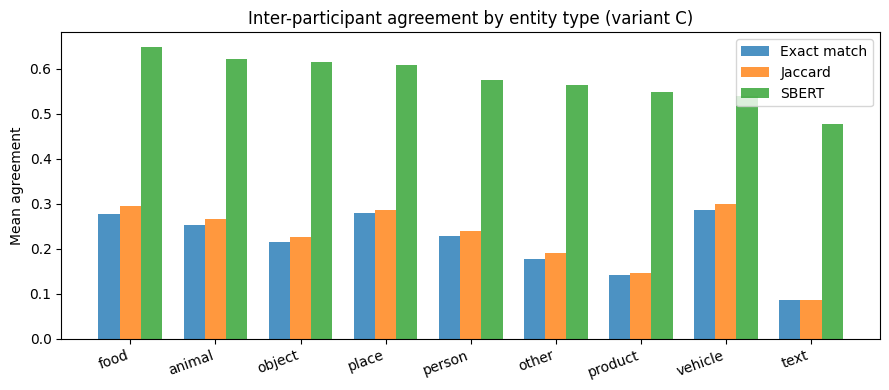

In [8]:
# ── Agreement by entity type ──────────────────────────────────────────────────
ent_map = df[['question_id', 'ent']].drop_duplicates().set_index('question_id')['ent']

ent_agree = agree['C'][['sbert', 'exact', 'jaccard']].join(ent_map).groupby('ent').mean()
ent_n     = agree['C'][['sbert']].join(ent_map).groupby('ent')['sbert'].count().rename('N')
ent_table = ent_agree.join(ent_n).sort_values('sbert', ascending=False)

print('Agreement by entity type (variant C, sorted by SBERT):')
print(ent_table.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ent_table))
w = 0.25
ax.bar(x - w, ent_table['exact'],   w, label='Exact match', alpha=0.8)
ax.bar(x,     ent_table['jaccard'], w, label='Jaccard',     alpha=0.8)
ax.bar(x + w, ent_table['sbert'],   w, label='SBERT',       alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ent_table.index, rotation=20, ha='right')
ax.set_ylabel('Mean agreement')
ax.set_title('Inter-participant agreement by entity type (variant C)')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# ── Top / bottom agreed questions ─────────────────────────────────────────────
q_en_map = {}
for p in participants:
    for a in p['answers']:
        if a.get('variant', 'C') == 'C':
            q_en_map[a['question_id']] = a.get('question_en', '')

N = 8
for label, ascending in [('LOWEST agreement', True), ('HIGHEST agreement', False)]:
    top = agree['C']['sbert'].sort_values(ascending=ascending).head(N)
    print(f'\n── {label} (SBERT, variant C) ──')
    for qid, score in top.items():
        answers = df[(df.question_id == qid) & (df.variant == 'C')]['answer_en'].dropna().tolist()
        unique  = sorted(set(answers))
        print(f'  [{score:.3f}] {q_en_map.get(qid, qid)}')
        print(f'    answers: {unique[:6]}')


── LOWEST agreement (SBERT, variant C) ──
  [0.195] What kind of information does the yellow and white book look like it contains?
    answers: ['Employment information', 'Explanation of the Eckman spiral', 'Forbidden book', 'History', 'Honeybees', 'Psychology']
  [0.246] What might a milkman have in common with the man with the backpack?
    answers: ['Both are men.', 'Bought shares of Cosmo Chemical.', 'Carrying a bag.', 'Carrying luggage', 'Carrying something.', 'Riding a bicycle.']
  [0.247] What does the man's gesture mean?
    answers: ['Agreement', 'It means encouragement.', "It means he doesn't know either.", 'It means to come into the room.', 'It means to run.', 'Okay']
  [0.249] What does the shirt say?
    answers: ['0', 'Brand name', 'English logo', 'It says nothing.', 'Love', 'The way to the future']
  [0.260] What letter is yellow and white?
    answers: ['Alphabet', 'Caution', 'Colored letter', 'Love', "McDonald's sign", 'Meaningless letters']
  [0.262] What is the name